In [1]:
#Importing the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squarify as sqr
import warnings
warnings.filterwarnings('ignore')

#Importing the data and cleaning it up by splitting each line and converting into a data frame
expenditures = pd.read_csv('expenditures.txt', header = None)
unemployment = pd.read_csv('unemployement-rate-1948-2010.csv')

labels = expenditures[0].str.split('\t').values[0]
lst = expenditures[0].str.split('\t').values[1:]
data_list = [a for a in lst]

exp = pd.DataFrame(data_list, columns = labels)
print(exp.head())
print(unemployment.head())

   year             category expenditure sex
0  2008                 Food        6443   1
1  2008  Alcoholic Beverages         444   1
2  2008              Housing       17109   1
3  2008              Apparel        1801   1
4  2008       Transportation        8604   1
     Series id  Year Period  Value
0  LNS14000000  1948    M01    3.4
1  LNS14000000  1948    M02    3.8
2  LNS14000000  1948    M03    4.0
3  LNS14000000  1948    M04    3.9
4  LNS14000000  1948    M05    3.5


In [2]:
#Constructing the treemap
#I will plot the expenditure proportions spent on different items in 2008

#Isolating the numbers and their category labels for building the treemap
#The categories from 008 will be used to build the treemap
expenses = exp[exp['year'] == '2008']['expenditure'].values
labels = exp[exp['year'] == '2008']['category']

#The numbers are strings, so they will be converted to integers
integer_list = [int(i) for i in expenses]

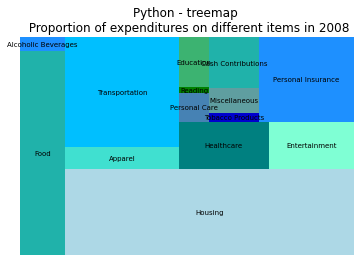

In [3]:
#Generating the treemap with a blue-green color scheme
color = ['lightseagreen', 'dodgerblue', 'lightblue', 'turquoise', 'deepskyblue', 'teal', 
         'aquamarine', 'steelblue', 'green', 'mediumseagreen', 'mediumblue', 'cadetblue']
sqr.plot(integer_list, label = labels, color = color, text_kwargs = {'fontsize' : 7})
plt.axis('off')
plt.title('Python - treemap \n Proportion of expenditures on different items in 2008')
plt.show()

In [4]:
#Constructing the area chart
#I will plot the unemployment rate over time
#I will use January of each year as the x-axis tick mark, so each year will have one value on the area chart

#Making the columns for the values and labels
#Jaunary of each year will be stored in a list to use as the x-axis labels
area_labels = [str(i) for i in unemployment[unemployment['Period'] == 'M01']['Year']]
rate = unemployment[unemployment['Period'] == 'M01']['Value']

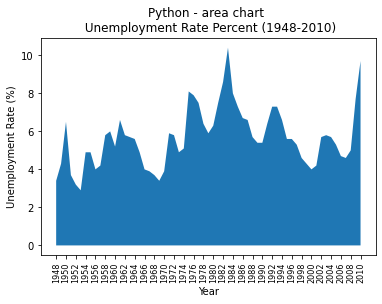

In [5]:
#Generating the area chart
plt.fill_between(area_labels, rate)
plt.locator_params(axis='x', nbins=2)
plt.xticks(area_labels[::2], fontsize = 8, rotation = 90)
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.title('Python - area chart \n Unemployment Rate Percent (1948-2010)')
plt.show()

In [6]:
#Constructing the stacked area chart
#I will plot the expenses for each year split by category

#Converting each string value in expenditures to an integer to allow for plotting
exp['expenditure'] = [int(i) for i in exp['expenditure']]

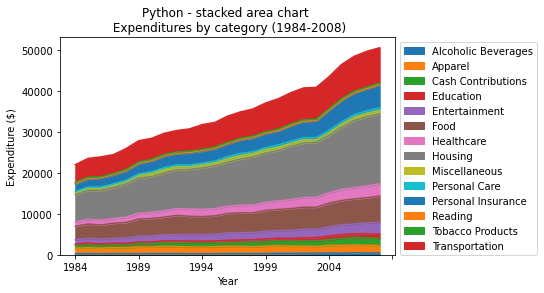

In [7]:
#Generating the stacked area chart

#Filtering each category expenditures into a list of lists
lst = [exp[exp['category'] == i]['expenditure'].values for i in np.unique(exp['category'])]

#Generating a data frame with this list of lists and plotting using pandas
df = pd.DataFrame(lst, index = np.unique(exp['category']), columns = np.unique(exp['year'])[::-1]).T.iloc[::-1]
df.plot.area()
plt.legend(loc = 'top', bbox_to_anchor = (1, 1))
plt.xlabel('Year')
plt.ylabel('Expenditure ($)')
plt.title('Python - stacked area chart \n Expenditures by category (1984-2008)')
plt.show()